#Run once

In [1]:
# Cell 1 — repo + dependencies
!git clone https://github.com/fickas/crab_project.git /content/marsh-crab 2>/dev/null || \
 (cd /content/marsh-crab && git pull)
!pip install -r /content/marsh-crab/requirements.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 15.8 MB/s eta 0:00:00


#Wait until marsh-crab shows up locally

In [2]:
# Cell 2 — Python setup
import sys
sys.path.insert(0, '/content/marsh-crab')
import marsh_utils as mu

##Run on changes

In [3]:
# Run this cell whenever you edit the repo
!cd /content/marsh-crab && git pull
import importlib
importlib.reload(mu)

Already up to date.


<module 'marsh_utils' from '/content/marsh-crab/marsh_utils.py'>

In [4]:
# Standard scientific Python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import json
import datetime

# Geospatial
import rasterio
from rasterio.mask import mask
from rasterio.features import rasterize
from rasterio.enums import Resampling
import geopandas as gpd
from shapely.geometry import box, mapping, Polygon
from shapely import wkt

# Image processing
import cv2
from PIL import Image

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Segmentation library
# May need to install: !pip install segmentation-models-pytorch
import segmentation_models_pytorch as smp

# Augmentation
# May need to install: !pip install albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Metrics
from sklearn.metrics import confusion_matrix, classification_report

# Settings
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.11.0+cu128


In [5]:
BATCH_SIZE = mu.recommended_batch_size()
BATCH_SIZE

GPU: NVIDIA L4  (23.7 GB VRAM)


8

In [6]:
base = "/content/drive/MyDrive/salt_marsh/crab_project/WEL/"

In [7]:
polygons_name = 'crab_polygons_2026-06-09_19-55-58.shp'   #from model 1

In [8]:
paths = {
    # Production drone imagery — high-altitude flight (forthcoming)
    "pan_orthomosaic":   f"{base}/wellfleet_normal/pan.tif",                # 4 cm
    "ms_orthomosaic":    f"{base}/wellfleet_normal/ms_5band.tif",           # ~8 cm
    "pansharp_ms":       f"{base}/wellfleet_normal/pansharp_5band.tif",     # 4 cm
    "dem":      f"{base}/wellfleet_normal/dem.tif",                # 4 cm

    # Bank-class labels — output from Model 1 (filtered by confidence threshold)
    "m1_polygons":       f"{base}/wellfleet_high_res/model1_predictions/{polygons_name}",

    # 'Other' class labels — hand-labeled in QGIS over the 4 cm imagery
    "other_handlabels":  f"{base}/wellfleet_normal/other_handlabels.shp",

    # Optional reference
    "channel_centerlines": f"{base}/wellfleet_normal/channel_centerlines.shp",

    # Output locations
    "runs_dir":  f"{base}/wellfleet_normal/runs",

}



#Synthetic data until have real


In [9]:
synthetic = True

In [10]:
if synthetic:
    syn_root = f"{base}/synthetic_test/wellfleet_normal_synthetic"
    paths["pan_orthomosaic"]     = f"{syn_root}/pan.tif"               # 4 cm
    paths["ms_orthomosaic"]      = f"{syn_root}/ms_5band.tif"          # 8 cm
    paths["pansharp_ms"]         = f"{syn_root}/pansharp_5band.tif"    # 4 cm
    paths["dem"]        = f"{syn_root}/dem_5m.tif"            # 4 cm
    paths["m1_polygons"]         = f"{base}/synthetic_test/wellfleet_high_res_synthetic/model1_predictions/{polygons_name}"
    paths["other_handlabels"]    = f"{syn_root}/other_handlabels.shp"
    paths["channel_centerlines"] = f"{syn_root}/channel_centerlines.shp"

    paths["runs_dir"]=  f"{syn_root}/runs"

In [11]:

# Create output directories
for key in ["runs_dir"]:
    os.makedirs(paths[key], exist_ok=True)

# Verify which input files exist (you'll have some, not others)
print("File existence check:")
for key, path in paths.items():
    exists = os.path.exists(path)
    status = "✓" if exists else "✗"
    print(f"  {status} {key}: {path}")

File existence check:
  ✓ pan_orthomosaic: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/pan.tif
  ✓ ms_orthomosaic: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/ms_5band.tif
  ✓ pansharp_ms: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/pansharp_5band.tif
  ✓ dem: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/dem_5m.tif
  ✓ m1_polygons: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/model1_predictions/crab_polygons_2026-06-09_19-55-58.shp
  ✓ other_handlabels: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/other_handlabels.shp
  ✓ channel_centerlines: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/channel_centerlines.shp
  ✓ tiles_dir: /content/drive/MyDr

In [12]:
EXPECTED = ['Blue', 'Green', 'Red', 'RedEdge', 'NIR']

with rasterio.open(paths["ms_orthomosaic"]) as src:
    print(src.count)         # 5
    print(src.descriptions)  # band names if the pipeline set them

    all_bands = src.read()           # whole raster, shape (5, H, W)
    nir_only  = src.read(5)          # just NIR, shape (H, W)
    print(all_bands.shape, nir_only.shape)

    if all(src.descriptions): assert list(src.descriptions) == EXPECTED, src.descriptions

5
('Blue', 'Green', 'Red', 'RedEdge', 'NIR')
(5, 1875, 1875) (1875, 1875)


In [13]:
class Config:
    # ── Class scheme (unchanged from M1) ──
    CLASS_COLUMN        = 'Class'
    CLASS_NAMES         = mu.CLASS_NAMES
    CLASSES             = mu.CLASSES
    CLASSES_OF_INTEREST = mu.CLASSES_OF_INTEREST
    PRIORITY            = mu.PRIORITY
    IGNORE_INDEX        = mu.IGNORE_INDEX
    QGIS_TO_MODEL       = mu.QGIS_TO_MODEL
    N_CLASSES           = len(mu.CLASS_NAMES)
    SEED                = mu.SEED

    # ── Resolution: M2 is the high-altitude flight ──
    RESOLUTION_CM = 4.0                                    # ← was 1.0 for M1

    # ── Bands ──
    # M2 pan is at 4cm, MS is at 8cm → pansharpened to 4cm; everything else
    # follows from pansharp_ms or dem_high_res as in M1.
    BAND_SPEC    = [('pan_orthomosaic', 1), ('ndvi', 1), ('ndre', 1)]

    PATCH_SIZE   = 512                                     # 20.5m × 20.5m physical extent at 4cm
    OVERLAP      = 0.5
    BATCH_SIZE   = BATCH_SIZE
    EPOCHS        = 100
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY  = 1e-4
    NUM_WORKERS   = 4

    # ── Loss ──
    CE_WEIGHT   = 1.0
    DICE_WEIGHT = 1.0

    # ── Augmentation ──
    USE_D4_AUGMENTATION = True

    # ── Architecture — fresh ImageNet, NOT M1 weights ──
    # M2 sees coarser GSD and (typically) a different band stack than M1,
    # so starting from M1's weights wouldn't help.
    ENCODER         = 'efficientnet-b3'
    ENCODER_WEIGHTS = 'imagenet'

    # ── Splitting — M2 extent is bigger, so blocks scale up ──
    BLOCK_SIZE_M   = 15 if synthetic else 100              # ← was 3 if synthetic
    TRAIN_FRAC     = 0.7
    VAL_FRAC       = 0.15
    TEST_FRAC      = 0.15
    REQUIRE_LABELS = True

    CONFIDENCE_THRESHOLDS = None

#Combine shapefiles

Model 1 predictions plus hand-labeled polys from flight 2.

In [14]:
import geopandas as gpd
import pandas as pd

# Load bank-class labels (from M1 in real mode, from synth ground truth in synth mode)
m1_polys = gpd.read_file(paths['m1_polygons'])

# Load 'other' labels (hand-drawn in QGIS for real, synthetic for testing)
other_polys = gpd.read_file(paths['other_handlabels'])

# Some M1 outputs might use 'class' lowercase; normalize the column name
if 'class' in m1_polys.columns and 'Class' not in m1_polys.columns:
    m1_polys = m1_polys.rename(columns={'class': 'Class'})

# Concatenate — both should have 'Class' and 'geometry' columns
combined_polys = gpd.GeoDataFrame(
    pd.concat([m1_polys, other_polys], ignore_index=True),
    crs=m1_polys.crs,
)
print(f"Loaded {len(m1_polys)} bank polygons + {len(other_polys)} 'other' polygons "
      f"= {len(combined_polys)} total")

Loaded 83 bank polygons + 9 'other' polygons = 92 total


In [15]:
print(f"Before fill: {combined_polys['Class'].value_counts().sort_index().to_dict()}")

if synthetic:
    # Ensure channel_mask exists
    mu.ensure_ndwi(paths, ms_key='pansharp_ms')
    mu.ensure_channel_mask_from_ndwi(paths, ndwi_key='ndwi')

    with rasterio.open(paths['ms_orthomosaic']) as src:
        bounds = box(*src.bounds)
    rng = np.random.default_rng(Config.SEED)

    combined_polys = mu.fill_missing_classes_from_channel_mask(
        combined_polys, bounds, paths['channel_mask'], rng,
        min_per_class=3,
    )
    print(f"After fill:  {combined_polys['Class'].value_counts().sort_index().to_dict()}")

Before fill: {1: 9, 3: 34, 4: 26, 5: 23}
  NDWI already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/ndwi.tif, skipping
  channel mask already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/channel_mask.tif, skipping


  Class 'healthy_bank' (QGIS=2): 0 existing, adding 3
  Class 'collapsed' (QGIS=6): 0 existing, adding 3
After fill:  {1: 9, 2: 3, 3: 34, 4: 26, 5: 23, 6: 3}


##Compute derived bands and save to disk (or just load)

##Choose bands to use for a specific run
<pre>
Config.BAND_SPEC = [
    ('pan_orthomosaic', 1),
    ('ndvi',            1),
    ('slope',           1),      # ← swap in
    ('savi',            1),      # ← or add a 4th
]
</pre>

In [16]:
paths = mu.ensure_indices(paths)

# ── Spectral indices (read from pansharp_ms) ──
mu.ensure_savi(paths,       ms_key='pansharp_ms')
mu.ensure_evi(paths,        ms_key='pansharp_ms')
mu.ensure_gndvi(paths,      ms_key='pansharp_ms')
mu.ensure_ndwi(paths,       ms_key='pansharp_ms')
mu.ensure_ci_rededge(paths, ms_key='pansharp_ms')

# ── DEM-derived ──
mu.ensure_tpi(paths, dem_key='dem', neighborhood_m=0.05, out_key='tpi_micro')
mu.ensure_tpi(paths, dem_key='dem', neighborhood_m=0.3,  out_key='tpi_small')
mu.ensure_tpi(paths, dem_key='dem', neighborhood_m=2.0,  out_key='tpi_large')

# Optional, only if you want a non-redundant slope signal:
# mu.ensure_slope(paths, dem_key='dem_high_res', smooth_sigma_m=0.05, out_key='slope')

# QGIS visualization only — don't put in BAND_SPEC:
mu.ensure_hillshade(paths, dem_key='dem')

# ── Channel-dependent (order matters: ndwi → channel_mask → the rest) ──
mu.ensure_ndwi(paths, ms_key='pansharp_ms')               # if not already done
mu.ensure_channel_mask_from_ndwi(paths, ndwi_key='ndwi')  # needs ndwi
mu.ensure_distance_to_channel(paths, channel_mask_key='channel_mask')
mu.ensure_relative_elevation(paths, dem_key='dem',
                                    channel_mask_key='channel_mask')

# ── Texture (from pan or any single-band raster) ──
mu.ensure_local_std(paths,  src_key='pan_orthomosaic', window_m=0.3)
mu.ensure_laplacian(paths,  src_key='pan_orthomosaic')

# Texture from pan brightness
mu.ensure_local_range(paths, src_key='pan_orthomosaic', window_m=0.3, out_key='pan_range')

# Topographic micro-relief (burrows!) from DEM
mu.ensure_local_range(paths, src_key='dem',    window_m=0.3, out_key='dem_range')

# Entropy of pan = visual texture complexity
mu.ensure_local_entropy(paths, src_key='pan_orthomosaic', window_m=0.3, out_key='pan_entropy')

# Existing function — DEM roughness via std
mu.ensure_local_std(paths, src_key='dem', window_m=0.3, out_key='dem_roughness')

NDVI:
  exists, skipping: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/ndvi.tif
NDRE:
  exists, skipping: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/ndre.tif
  SAVI already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/savi.tif, skipping
  EVI already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/evi.tif, skipping
  GNDVI already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/gndvi.tif, skipping
  NDWI already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/ndwi.tif, skipping
  CIred-edge already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/ci_rededge.tif, skipping
  TPI already exists at /content/drive/M

{'pan_orthomosaic': '/content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/pan.tif',
 'ms_orthomosaic': '/content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/ms_5band.tif',
 'pansharp_ms': '/content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/pansharp_5band.tif',
 'dem': '/content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/dem_5m.tif',
 'm1_polygons': '/content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_high_res_synthetic/model1_predictions/crab_polygons_2026-06-09_19-55-58.shp',
 'other_handlabels': '/content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/other_handlabels.shp',
 'channel_centerlines': '/content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/channel_centerlines.shp',
 'tiles_dir': '/content/drive/MyDrive/salt

In [17]:
new_keys = ['savi', 'evi', 'gndvi', 'ndwi', 'ci_rededge',
            'tpi_micro', 'tpi_small', 'tpi_large',
            'hillshade', 'channel_mask', 'dist_to_channel',
            'rel_elevation', 'local_std', 'laplacian']
missing = [k for k in new_keys if k not in paths]
print(f"Missing: {missing or 'none — all bands registered'}")

Missing: none — all bands registered


In [18]:
# Check what's in the orthomosaic

# Run on each available file
for key in ["ms_orthomosaic", "pan_orthomosaic", "dem"]:
    if os.path.exists(paths[key]):
        mu.inspect_raster(paths[key])


=== /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/ms_5band.tif ===
  Bounds: BoundingBox(left=409925.0, bottom=4642425.0, right=410075.0, top=4642575.0)
  Size: 1875 × 1875 pixels
  Resolution: 0.0800 × 0.0800
  CRS: EPSG:26919
  Bands: 5
  Dtype: ('uint16', 'uint16', 'uint16', 'uint16', 'uint16')
  Nodata: None
  Ground area: 150.0m × 150.0m

=== /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/pan.tif ===
  Bounds: BoundingBox(left=409925.0, bottom=4642425.0, right=410075.0, top=4642575.0)
  Size: 3750 × 3750 pixels
  Resolution: 0.0400 × 0.0400
  CRS: EPSG:26919
  Bands: 1
  Dtype: ('uint16',)
  Nodata: None
  Ground area: 150.0m × 150.0m

=== /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/dem_5m.tif ===
  Bounds: BoundingBox(left=409925.0, bottom=4642425.0, right=410075.0, top=4642575.0)
  Size: 3750 × 3750 pixels
  Resolution: 0.0400 × 0.0400

#Block-based spatial splits


The block ID is (x // block_size, y // block_size). Two patches in the same block always go to the same split. A patch crossing a block boundary gets assigned by its center, so up to ~patch_size / 2 worth of pixels can leak into an adjacent block's split — at 256px × 1cm GSD that's 1.28m of leakage near 100m block boundaries, which is negligible.

#Patch generator with split assignments

The two-pass structure is so the block assignment is computed over the full set of blocks the raster touches, before any patches are yielded. Otherwise an early yielded patch's split could depend on which blocks get seen later, which would not be deterministic.

In [19]:
print(combined_polys.columns.tolist())
print(combined_polys.iloc[0])
print(combined_polys[Config.CLASS_COLUMN].value_counts())

['Class', 'class_name', 'threshold', 'mean_confi', 'area_m2', 'geometry']
Class                                                         3
class_name                                            crab_edge
threshold                                                   0.8
mean_confi                                              0.97867
area_m2                                                 13.9993
geometry      POLYGON ((409977.26 4642502.6, 409977.32 46425...
Name: 0, dtype: object
Class
3    34
4    26
5    23
1     9
2     3
6     3
Name: count, dtype: int64


In [20]:
polys_gdf = combined_polys

###Map to 0-based

In [21]:


# Map QGIS-side class values (1..6) to model class indices (0..5)
QGIS_TO_MODEL = {i:i-1 for i in range(1, len(Config.CLASS_NAMES)+1)}
print(f'{QGIS_TO_MODEL=}')

polys_gdf[Config.CLASS_COLUMN] = polys_gdf[Config.CLASS_COLUMN].map(QGIS_TO_MODEL)

# Catch unmapped values before they become silent bugs
if polys_gdf[Config.CLASS_COLUMN].isna().any():
    bad = polys_gdf.loc[polys_gdf[Config.CLASS_COLUMN].isna(), Config.CLASS_COLUMN].unique()
    raise ValueError(f"Unmapped class values from QGIS: {bad}")

polys_gdf[Config.CLASS_COLUMN] = polys_gdf[Config.CLASS_COLUMN].astype(int)

print(f"Class distribution:\n{polys_gdf[Config.CLASS_COLUMN].value_counts().sort_index()}")


QGIS_TO_MODEL={1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}
Class distribution:
Class
0     9
1     3
2    34
3    26
4    23
5     3
Name: count, dtype: int64


###Filter classes

Decide if whether to collapse classes into a subset.

In [22]:
filter_classes = False

In [23]:
if filter_classes:
  original_class_column = polys_gdf[Config.CLASS_COLUMN].copy()
  new_labels_master = []
  mapping = dict(zip(range(0,5), [1,0,2,2,2]))  #3 class - 2 will be dropped
  for i,label in enumerate(original_class_column):
    mapped_label = mapping[label]
    if mapped_label==2: continue  #skip
    new_labels_master.append(mapped_label)

  CLASS_NAMES = {
    0: 'healthy_bank',
    1: 'eroding_non_crab',
    2: 'collapsed',
  }

  polys_gdf[Config.CLASS_COLUMN] = np.array(new_labels_master)
  print(f"Class distribution:\n{polys_gdf[Config.CLASS_COLUMN].value_counts().sort_index()}")

In [24]:

# 1. Generate patches with splits
patches = list(mu.build_patches_with_splits_multi(
    paths=paths,
    polygons_gdf=polys_gdf,
    cfg=Config,
))

# 2. Sanity-check coverage
mu.summarize_patches(patches, class_names=Config.CLASS_NAMES)

# 3. Split into train/val/test
train_patches = [p for p in patches if p['split'] == 'train']
val_patches   = [p for p in patches if p['split'] == 'val']
test_patches  = [p for p in patches if p['split'] == 'test']

# 4. Compute (or load cached) normalization stats from training patches
stats_path = f"{base}/synthetic_test/wellfleet_normal_synthetic/channel_stats.json" if synthetic else f"{base}/wellfleet_normal/channel_stats.json"
channel_means, channel_stds = mu.compute_channel_stats(train_patches, stats_path)

# 5. Build datasets and loaders
train_ds = mu.MarshSegmentationDataset(train_patches, augmentation=mu.get_augmentations('train', channel_means, channel_stds))
val_ds   = mu.MarshSegmentationDataset(val_patches,   augmentation=mu.get_augmentations('val',   channel_means, channel_stds))
test_ds  = mu.MarshSegmentationDataset(test_patches,  augmentation=mu.get_augmentations('test',  channel_means, channel_stds))

train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True,  num_workers=Config.NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True)

Total patches: 109
Splits: {'train': 76, 'val': 22, 'test': 11}

--- train: 76 patches, 19,922,944 pixels
  class   0 other                   2,194,982 (11.02%)
  class   1 healthy_bank                8,035 ( 0.04%)
  class   2 eroding_non_crab          264,301 ( 1.33%)
  class   3 crab_edge                 213,560 ( 1.07%)
  class   4 crab_platform             131,629 ( 0.66%)
  class   5 collapsed                   5,617 ( 0.03%)
  ignore (255)             17,104,820 (85.85%)

--- val: 22 patches, 5,767,168 pixels
  class   0 other                     622,594 (10.80%)
  class   1 healthy_bank                1,637 ( 0.03%)
  class   2 eroding_non_crab          136,718 ( 2.37%)
  class   3 crab_edge                  48,877 ( 0.85%)
  class   4 crab_platform              82,511 ( 1.43%)
  class   5 collapsed                   3,783 ( 0.07%)
  ignore (255)              4,871,048 (84.46%)

--- test: 11 patches, 2,883,584 pixels
  class   0 other                     311,856 (10.81%)
  clas

###What to look for in smoke test

Once you've run the summary, three things to look for in the output:

* Are split sizes roughly proportional to your fractions (70/15/15)? If one block is huge relative to others, you may get an imbalanced split.
* Is each class present in every split? Empty val classes mean noisy IoU for that class.
* What does labeled_fraction look like? If most patches are less than 10% labeled, the model is mostly seeing ignore — you may want to filter more aggressively or oversample patches with high labeled_fraction.

* Many fewer patches than expected → tile labels don't cover most of the DEM and require_labels=True is dropping them. Lower the threshold to accept partially-labeled patches, or set require_labels=False to see what's there.

* Empty classes in val or test → block split landed unluckily. Try a different seed, or check whether the offending class is concentrated in a small geographic area (in which case a different split strategy might be warranted).

##Get stats for later normalization

#Start of training

## Model + optimizer + scheduler

In [25]:
import segmentation_models_pytorch as smp

LR          = Config.LEARNING_RATE
WEIGHT_DECAY = 1e-4

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = smp.Unet(
    encoder_name=Config.ENCODER,
    encoder_weights=Config.ENCODER_WEIGHTS,
    in_channels=len(Config.BAND_SPEC),    # 3 for (Pan, NDVI, NDRE)
    classes=Config.N_CLASSES,
).to(device)

criterion = mu.CombinedLoss(
    num_classes=Config.N_CLASSES,
    ignore_index=255,
    ce_weight=1.0,
    dice_weight=1.0,
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=Config.EPOCHS)

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

## Run it

In [26]:
ckpt_path=paths['runs_dir'] + '/best_model.pt'

In [27]:
best_iou = mu.train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=Config.EPOCHS,
    num_classes=Config.N_CLASSES,
    ignore_index=255,
    ckpt_path=ckpt_path,
    device=device,
    class_names=Config.CLASS_NAMES,
)
print(f"Best val mIoU: {best_iou:.4f}")

/content/marsh-crab/marsh_utils.py:1307: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch   1/100  train_loss=2.4421  val_loss=2.7766  val_mIoU=0.0753  |  other=0.034, healthy_bank=0.001, eroding_non_crab=0.020, crab_edge=0.004, crab_platform=0.221, collapsed=0.001
  → saved checkpoint  (val_mIoU=0.0753)
Epoch   2/100  train_loss=2.1058  val_loss=2.2160  val_mIoU=0.1009  |  other=0.656, healthy_bank=0.001, eroding_non_crab=0.207, crab_edge=0.029, crab_platform=0.269, collapsed=0.005
  → saved checkpoint  (val_mIoU=0.1009)
Epoch   3/100  train_loss=1.9591  val_loss=1.9788  val_mIoU=0.1295  |  other=0.756, healthy_bank=0.003, eroding_non_crab=0.298, crab_edge=0.071, crab_platform=0.307, collapsed=0.010
  → saved checkpoint  (val_mIoU=0.1295)
Epoch   4/100  train_loss=1.7693  val_loss=1.8805  val_mIoU=0.1451  |  other=0.850, healthy_bank=0.005, eroding_non_crab=0.281, crab_edge=0.097, crab_platform=0.326, collapsed=0.013
  → saved checkpoint  (val_mIoU=0.1451)
Epoch   5/100  train_loss=1.5895  val_loss=1.8808  val_mIoU=0.1492  |  other=0.874, healthy_bank=0.011, eroding_

##Watch list

* Loss going down. If it doesn't decrease over the first 3-5 epochs, something's wrong with the loss/optimizer/data. Most likely culprits: NaN in normalized inputs, label values outside [0, num_classes-1] ∪ {ignore_index}, learning rate way off.

* Train mIoU gt val mIoU as expected. If val tracks train almost exactly, your block-based splits aren't separating well enough — leakage. If val crashes far below train, you're overfitting and want more augmentation or fewer epochs.

* Per-class IoU. Rare classes (collapsed, eroding_non_crab maybe) will have noisier IoU. If a class stays at 0.0 IoU across epochs, the model isn't learning it — usually because there are too few pixels of it in train, or your class weights are pushing the model away from it.

##Need more than mIoU

The most useful metric isn't mIoU on the test set — it's precision at high-confidence thresholds. Specifically: "for pixels where Model 1 predicts class 3 with softmax ≥ 0.7, what fraction actually are class 3?" That high-confidence subset is what becomes Model 2's training data, and any false positives there poison Model 2.

So in addition to training-time mIoU, the right evaluation summary for Model 1 is a precision-coverage curve:

* x-axis: confidence threshold (0.5, 0.6, ..., 0.95)
* y-axis: per-class precision at that threshold

Annotated with coverage (what fraction of the marsh you keep at each threshold)

This tells you exactly how strict the threshold needs to be to get acceptably clean labels for Model 2, and how much area you sacrifice at each strictness level. If at threshold 0.7 you get 95% precision on class 3 but only cover 12% of the marsh, that might still be enough labels for Model 2 because the marsh is big.

Loaded checkpoint from epoch 70, val mIoU = 0.4414
Per-class IoU: [0.9984668406170167, 0.48381788258454095, 0.7733108270372154, 0.5880998964200098, 0.7002103254616316, 0.03574244415149166]

Precision-coverage analysis on val set:

Class 3 (crab_edge):
  threshold   precision      recall    coverage
       0.50      0.6371      0.9353      0.0801
       0.60      0.6601      0.9305      0.0769
       0.70      0.6865      0.9249      0.0735
       0.75      0.7021      0.9225      0.0717
       0.80      0.7204      0.9187      0.0695
       0.85      0.7438      0.9130      0.0669
       0.90      0.7743      0.9039      0.0637
       0.95      0.8239      0.8832      0.0585

Class 4 (crab_platform):
  threshold   precision      recall    coverage
       0.50      0.8760      0.7740      0.0813
       0.60      0.8838      0.7606      0.0792
       0.70      0.8934      0.7461      0.0769
       0.75      0.8983      0.7371      0.0756
       0.80      0.9050      0.7269      0.0740
  

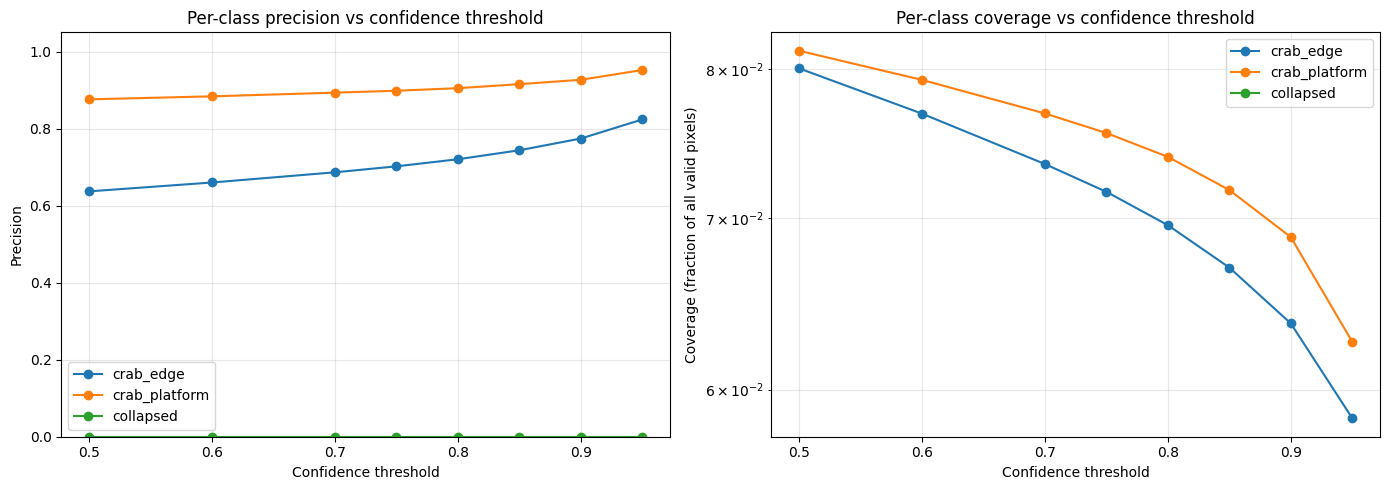

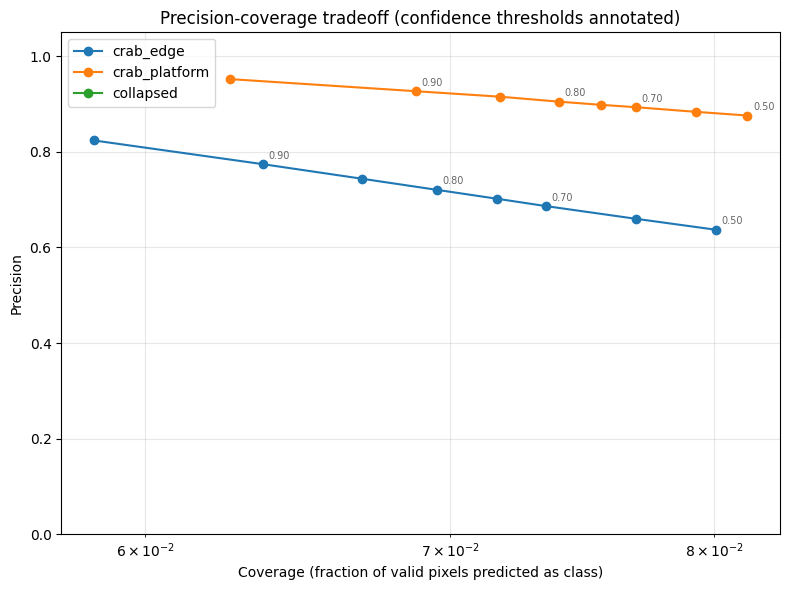

In [28]:
# ============ After train() completes ============

# 1. Reload the best checkpoint into the model (in case last epoch wasn't best)
best_ckpt = torch.load(ckpt_path, map_location=device)
state_dict = best_ckpt.get('model_state_dict', best_ckpt) if isinstance(best_ckpt, dict) else best_ckpt
model.load_state_dict(state_dict)
print(f"Loaded checkpoint from epoch {best_ckpt['epoch']}, "
      f"val mIoU = {best_ckpt['best_iou']:.4f}")
print(f"Per-class IoU: {best_ckpt['iou_per_class']}")

# 2. Run precision-coverage on the validation set to choose thresholds
print("\nPrecision-coverage analysis on val set:")
pc_results_val = mu.evaluate_precision_coverage(
    model=model,
    loader=val_loader,
    num_classes=Config.N_CLASSES,
    ignore_index=Config.IGNORE_INDEX,
    device=device,
)

# Visualize so you can sanity-check before committing thresholds
mu.plot_precision_coverage(
    pc_results_val,
    class_names=Config.CLASS_NAMES,
    classes_of_interest=Config.CLASSES_OF_INTEREST,
)
mu.plot_precision_vs_coverage(
    pc_results_val,
    class_names=Config.CLASS_NAMES,
    classes_of_interest=Config.CLASSES_OF_INTEREST,
)
mu.print_precision_coverage_table(
    pc_results_val,
    class_names=Config.CLASS_NAMES,
    classes_of_interest=Config.CLASSES_OF_INTEREST,
)

# 3. Auto-pick thresholds at a precision floor of your choice
TARGET_PRECISION = 0.9
print(f"\nChosen thresholds (target precision = {TARGET_PRECISION}):")
Config.CONFIDENCE_THRESHOLDS = mu.pick_thresholds(
    pc_results_val,
    classes_of_interest=Config.CLASSES_OF_INTEREST,
    target_precision=TARGET_PRECISION,
)

# 4. (Optional) Verify on the held-out test set so the precision numbers
#    you report aren't from the same data you tuned thresholds on
print("\nVerification on test set (using thresholds chosen from val):")
pc_results_test = mu.evaluate_precision_coverage(
    model=model,
    loader=test_loader,
    num_classes=Config.N_CLASSES,
    ignore_index=Config.IGNORE_INDEX,
    device=device,
)
mu.print_precision_coverage_table(
    pc_results_test,
    class_names=Config.CLASS_NAMES,
    classes_of_interest=Config.CLASSES_OF_INTEREST,
)


In [29]:

# 5. NOW save artifacts — Config.CONFIDENCE_THRESHOLDS is populated
from datetime import datetime
date_name = f'{datetime.now():%Y-%m-%d_%H-%M-%S}/'

artifact_dir = f'{paths["runs_dir"]}/run_{date_name}/'

os.makedirs(artifact_dir, exist_ok=True)
print(f"Run output: {artifact_dir}")

mu.save_training_artifacts(
    output_dir=artifact_dir,
    model=model,
    channel_means=channel_means,
    channel_stds=channel_stds,
    training_summary={
        'best_val_miou':     float(best_iou),
        'iou_per_class':     best_ckpt['iou_per_class'],
        'num_train_patches': len(train_patches),
        'num_val_patches':   len(val_patches),
        'num_test_patches':  len(test_patches),
        'target_precision':  TARGET_PRECISION,
    },
    cfg=Config,
)

Run output: /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/runs/run_2026-06-10_16-43-13//
Saved artifacts to /content/drive/MyDrive/salt_marsh/crab_project/WEL//synthetic_test/wellfleet_normal_synthetic/runs/run_2026-06-10_16-43-13//


###How to interpret the output for your Model 2 labeling decision

The tradeoff plot is the actionable one. Each line is a class; each point is a confidence threshold. The point you want to pick for that class's Model 2 labels is the one where precision is "high enough" (say 0.9+) at the highest possible coverage. If class 3 hits 0.95 precision at coverage 0.05 (5% of marsh pixels labeled), and class 5 only hits 0.7 precision at any threshold, you'd commit class-3 labels to Model 2 confidently and either gather more data for class 5 or accept noisier class-5 labels.

The threshold annotations on the tradeoff plot make this concrete: "to get class 3 at precision ≥ 0.9, threshold at 0.75, which keeps 4% of marsh pixels." That's a sentence you can put in a report.

You might also find that different classes need different thresholds — that's expected, and the per-class precision curve is exactly the right tool for setting them. The standard "single threshold for all classes" rule of thumb (e.g., 0.7) is a starting point, not the final answer.

#Analyze channel importance

In [30]:
CHANNEL_NAMES = ['0', '1', '2']

In [31]:

# Quick pass: zero ablation
zero_results = mu.channel_zero_ablation(
    model=model, loader=val_loader,
    num_classes=Config.N_CLASSES,
    classes_of_interest=Config.CLASSES_OF_INTEREST,
    channel_names=CHANNEL_NAMES,
    device=device,
)

print(f"Baseline mIoU: {zero_results['baseline_mean_iou']:.4f}")
for name, r in zero_results['per_channel'].items():
    print(f"  zero {name:6s}: mIoU={r['mean_iou']:.4f}  drop={r['drop_from_base']:+.4f}")

# Slower pass: permutation importance
perm_results = mu.channel_permutation_importance(
    model=model, loader=val_loader,
    num_classes=Config.N_CLASSES,
    classes_of_interest=Config.CLASSES_OF_INTEREST,
    channel_names=CHANNEL_NAMES,
    device=device,
    n_repeats=3,
)

print(f"\nPermutation importance (mean ± std over {3} repeats):")
for name, r in perm_results['per_channel'].items():
    print(f"  permute {name:6s}: drop={r['mean_drop']:+.4f} ± {r['std_drop']:.4f}")

Baseline mIoU: 0.4419
  zero 0     : mIoU=0.1134  drop=+0.3284
  zero 1     : mIoU=0.1733  drop=+0.2685
  zero 2     : mIoU=0.4045  drop=+0.0373

Permutation importance (mean ± std over 3 repeats):
  permute 0     : drop=+0.2532 ± 0.0026
  permute 1     : drop=+0.2513 ± 0.0078
  permute 2     : drop=+0.1687 ± 0.0081


##How to interpret the output:

* Big drop when zeroed → model relies heavily on that channel (could be true importance or learned reliance)
* Small drop when zeroed → model isn't using that channel much (might be genuinely useless, or might be that the model leans on other correlated channels)
* Big drop when permuted, small drop when zeroed → model is using the channel's spatial structure but is partially robust to scaling
* Both large → channel is genuinely important
* Both small → channel is probably redundant

A useful pattern is comparing the two: if zeroing gives a big drop but permutation gives a small one, the model is leaning on the channel's value range more than its spatial pattern. This sometimes flags problems — e.g., the model has learned "if NDVI value is low, prediction is X" without using the spatial pattern, which is a clue that the channel is acting more like a scalar gate than a spatial feature.

###When to escalate to retrain ablation:

If zero+permutation suggest a channel might be droppable (mean IoU drop < ~0.01 across both tests), do one retrain without that channel and compare the new baseline. If the retrained model matches the original, drop the channel. If the retrained model loses meaningful IoU even though the inference ablation suggested the channel was unused, the trained model was using it in ways the inference tests didn't capture. Retrain is more expensive but it's the only test that tells you whether a channel should have been there during training.

For the Pan/NDVI/NDRE setup specifically, my prior is that NDVI does the heaviest lifting (vegetation contrast is the cleanest signal), NDRE adds modest value (matters for stress within the vegetated regime), and pan adds spatial resolution that the others can't replace. But that prior is worth nothing compared to actually running the ablation once you have data.

In [32]:
results = mu.channel_permutation_importance_per_class(
    model, val_loader, num_classes=6,
    ignore_index=Config.IGNORE_INDEX,
    n_repeats=3,
    device=device,
    class_names=Config.CLASS_NAMES,                # dict {0:'other', 1:'healthy_bank', ...}
    band_names=[b[0] for b in Config.BAND_SPEC],   # ['pan_orthomosaic', 'ndvi', 'ndre']
)
# results['drops_mean'][ch, c]   → drop for channel ch on class c
# results['drops'][ch, c, :]     → per-repeat drops (for variance / significance testing)

Baseline per-class IoU:
  other                0.9985
  healthy_bank         0.4907
  eroding_non_crab     0.7737
  crab_edge            0.5885
  crab_platform        0.7005
  collapsed            0.0365

Per-class permutation drops (mean ± std over 3 repeats):
       channel           other    healthy_bank  eroding_non_cr       crab_edge   crab_platform       collapsed
  pan_orthomosaic    +0.049±0.016    +0.457±0.043    +0.500±0.023    +0.349±0.004    +0.416±0.045    +0.020±0.007
          ndvi    +0.398±0.072    +0.490±0.000    +0.373±0.030    +0.443±0.023    +0.580±0.040    +0.019±0.009
          ndre    +0.110±0.027    +0.398±0.110    +0.138±0.039    +0.168±0.031    +0.352±0.042    +0.015±0.010


#Experiment with different thresholding approaches

In [33]:
def predict_probs(model, loader, ignore_index=255, device='cuda'):
    """Run the model and return per-pixel (probs, true_label).

    Returns:
      probs: (N, num_classes) float32 softmax probabilities
      true:  (N,) int64 ground truth labels
    """
    import torch, numpy as np
    model.eval()
    all_probs, all_true = [], []
    with torch.no_grad():
        for batch in loader:
            # Support both tuple and dict batch formats
            if isinstance(batch, dict):
                x, y = batch['image'], batch['mask']
            else:
                x, y = batch[0], batch[1]
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            probs  = torch.softmax(logits, dim=1).permute(0, 2, 3, 1)   # (B,H,W,C)
            mask   = (y != ignore_index)
            all_probs.append(probs[mask].cpu().numpy())
            all_true.append(y[mask].cpu().numpy())
    return np.concatenate(all_probs), np.concatenate(all_true)

def rule_argmax(probs):
    return probs.argmax(axis=1)

def rule_soft_cascade(probs, bank_threshold=0.5, bank_classes=(1, 2, 3, 4, 5)):
    """If sum of bank probs > threshold, argmax among bank classes; else 'other'."""
    import numpy as np
    p_bank_sum = probs[:, list(bank_classes)].sum(axis=1)
    bank_mask  = np.zeros(probs.shape[1], dtype=bool); bank_mask[list(bank_classes)] = True
    masked = np.where(bank_mask[None, :], probs, -np.inf)
    bank_argmax = masked.argmax(axis=1)
    return np.where(p_bank_sum > bank_threshold, bank_argmax, 0)

def rule_priority(probs, thresholds, priority, default_threshold=0.5):
    """Walk classes in priority order; first to pass its threshold wins.
    Classes without an explicit threshold use `default_threshold`.
    Accepts thresholds as a dict OR an array."""
    import numpy as np
    pred = np.zeros(probs.shape[0], dtype=np.int64)
    decided = np.zeros(probs.shape[0], dtype=bool)
    for cls in priority:
        if isinstance(thresholds, dict):
            thr = thresholds.get(cls, default_threshold)
        else:
            thr = thresholds[cls] if cls < len(thresholds) else default_threshold
        passes = (probs[:, cls] > thr) & ~decided
        pred[passes] = cls
        decided     |= passes
    return pred


=== argmax ===


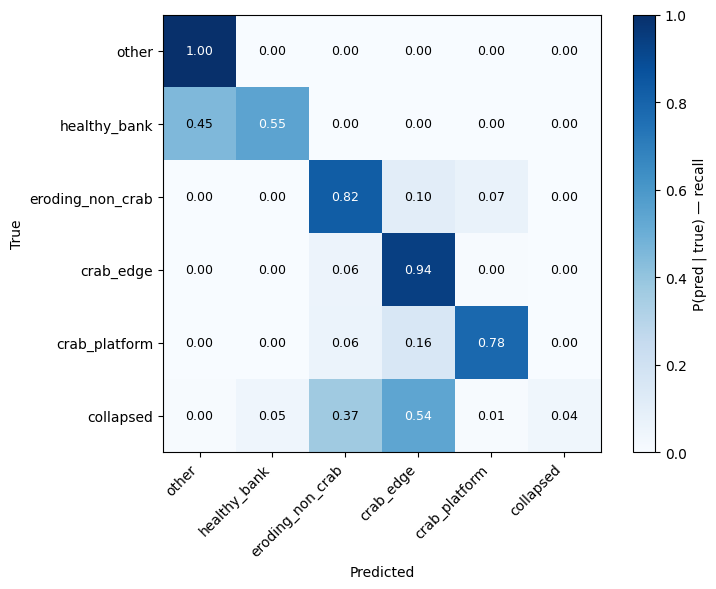


=== soft_cascade_05 ===


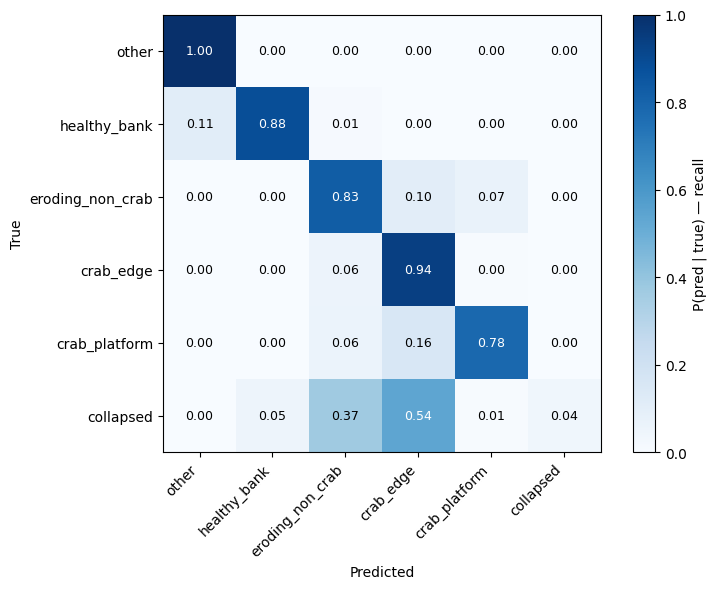


=== soft_cascade_07 ===


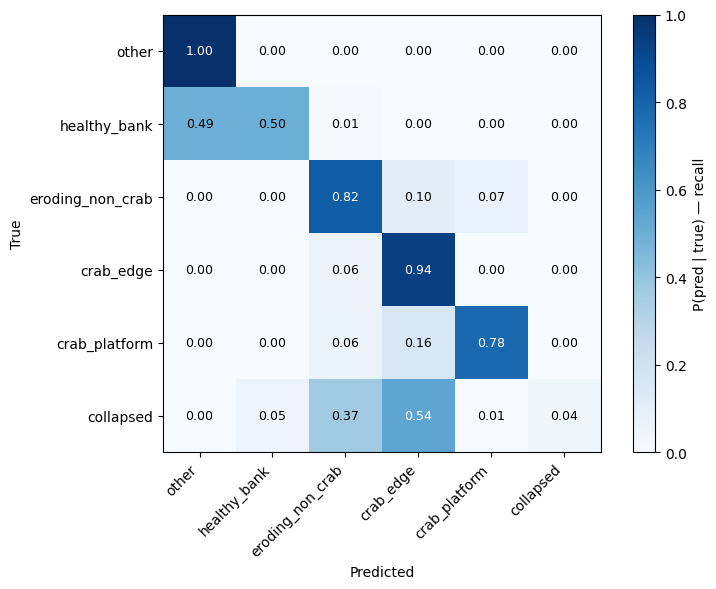


=== priority_all ===


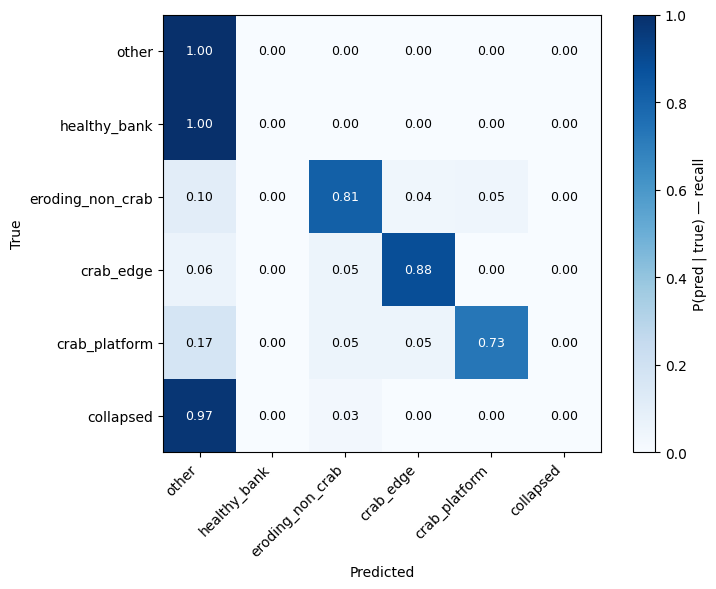


=== priority_crab_only ===


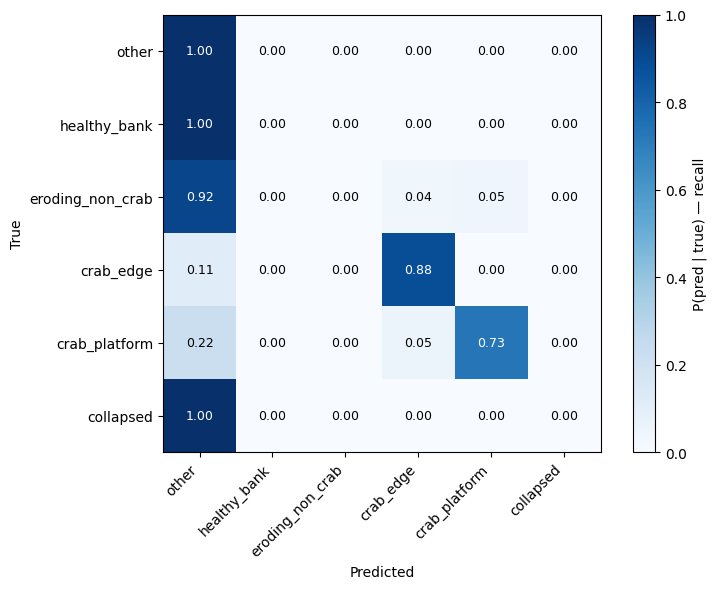

In [34]:
import sklearn

# Compute probs once
probs, true = predict_probs(model, val_loader, ignore_index=Config.IGNORE_INDEX, device=device)

# Try different rules — fast since model doesn't run again
for rule_name, rule_fn in [
    ('argmax',             lambda p: rule_argmax(p)),
    ('soft_cascade_05',    lambda p: rule_soft_cascade(p, bank_threshold=0.5)),
    ('soft_cascade_07',    lambda p: rule_soft_cascade(p, bank_threshold=0.7)),
    ('priority_all',       lambda p: rule_priority(p, Config.CONFIDENCE_THRESHOLDS, Config.PRIORITY)),
    ('priority_crab_only', lambda p: rule_priority(p, Config.CONFIDENCE_THRESHOLDS, [5, 4, 3])),
]:
    pred = rule_fn(probs)
    cm = sklearn.metrics.confusion_matrix(true, pred, labels=range(len(Config.CLASS_NAMES)))
    print(f"\n=== {rule_name} ===")
    mu.display_confusion_matrix(cm, list(Config.CLASS_NAMES.values()), normalize='recall')

#Look at confidence levels


=== argmax ===
  Pixels: 896,120/896,120 kept  ·  0 abstained (0.0%)


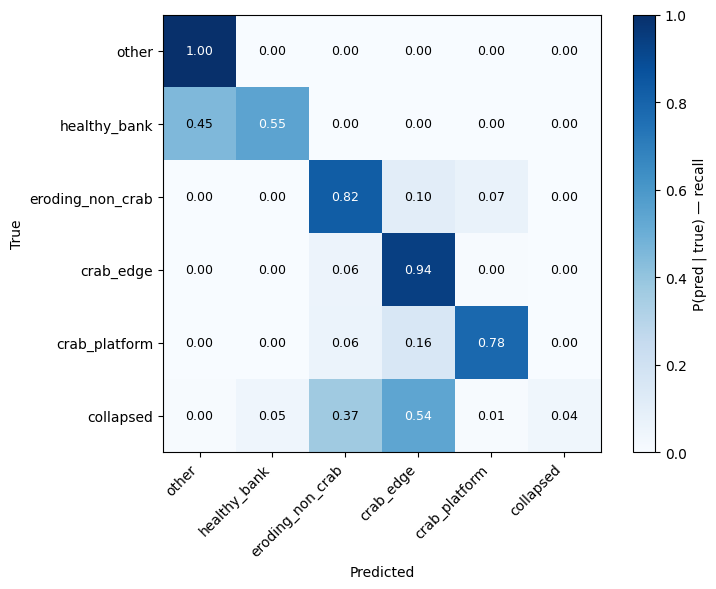


=== argmax_abstain_05 ===
  Pixels: 885,812/896,120 kept  ·  10,308 abstained (1.2%)


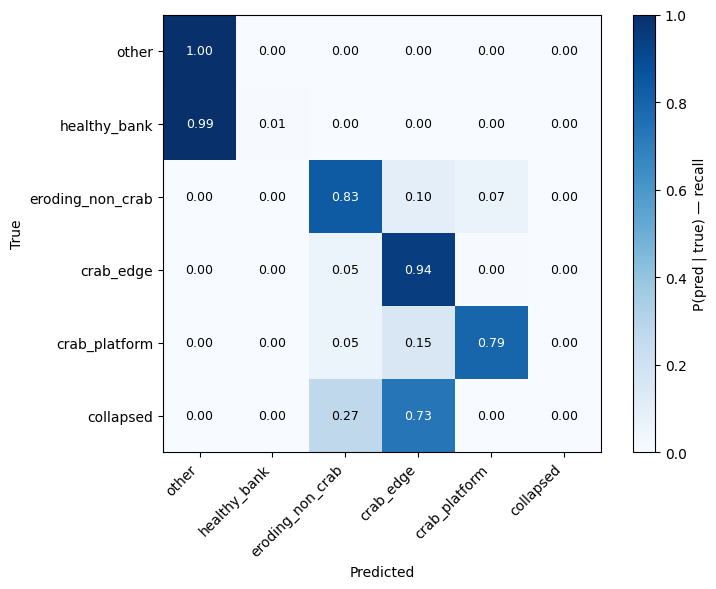


=== argmax_abstain_07 ===
  Pixels: 870,224/896,120 kept  ·  25,896 abstained (2.9%)


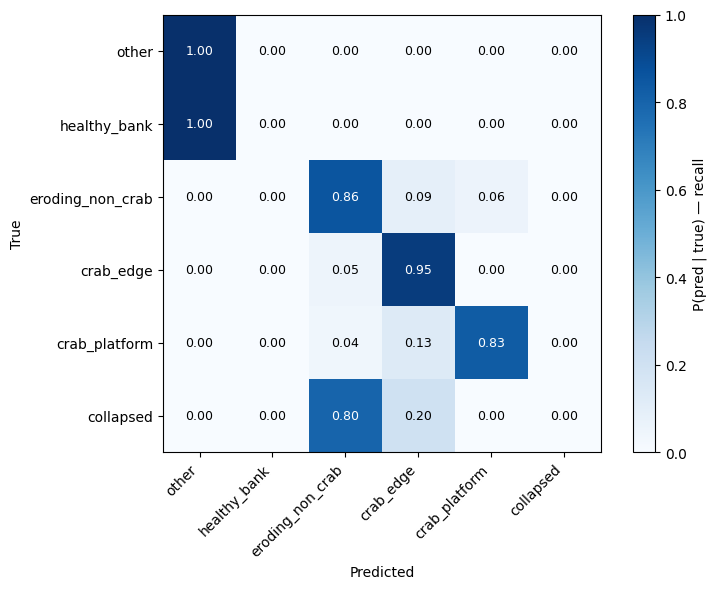


=== margin_abstain_015 ===
  Pixels: 885,521/896,120 kept  ·  10,599 abstained (1.2%)


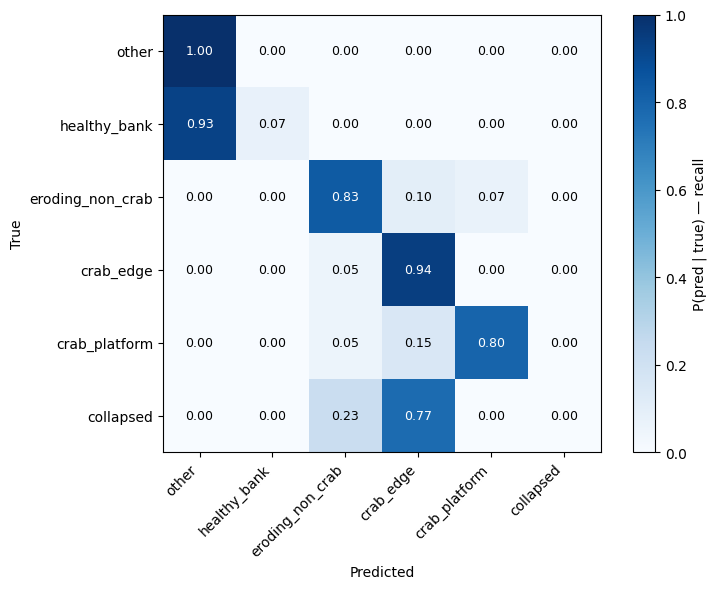


=== margin_abstain_025 ===
  Pixels: 880,977/896,120 kept  ·  15,143 abstained (1.7%)


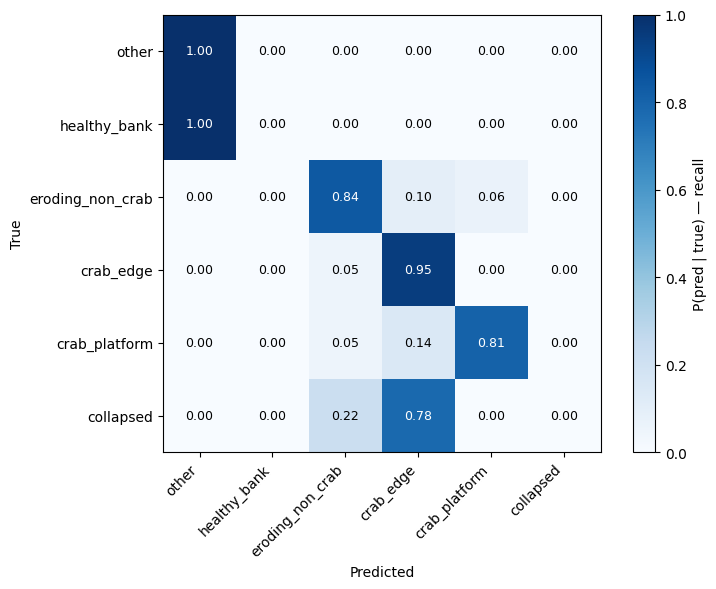


=== entropy_abstain_15 ===
  Pixels: 892,385/896,120 kept  ·  3,735 abstained (0.4%)


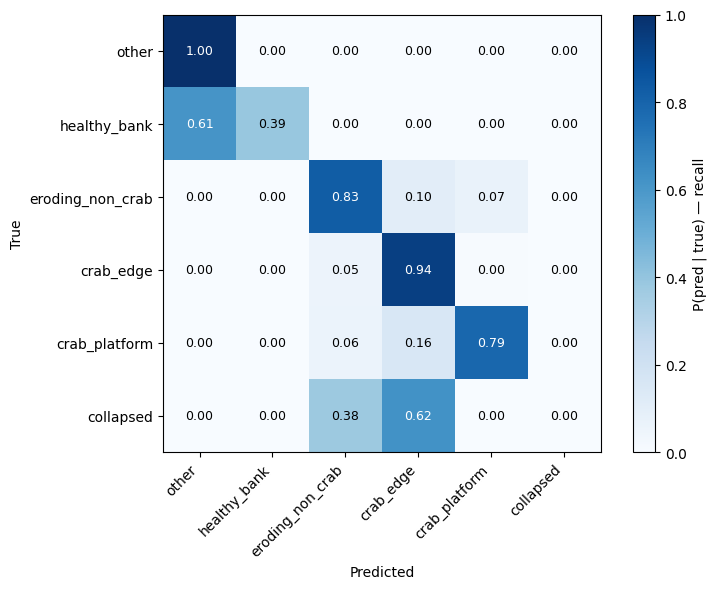


=== soft_cascade_05 ===
  Pixels: 896,120/896,120 kept  ·  0 abstained (0.0%)


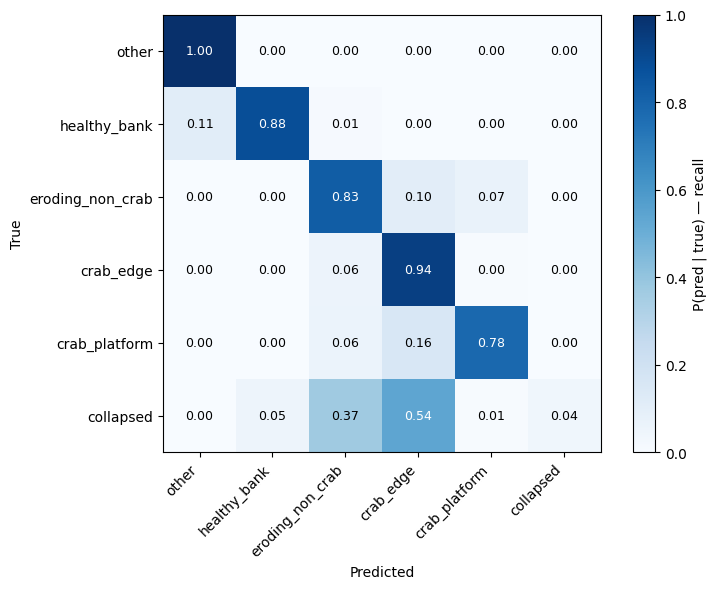


=== soft_cascade_07 ===
  Pixels: 896,120/896,120 kept  ·  0 abstained (0.0%)


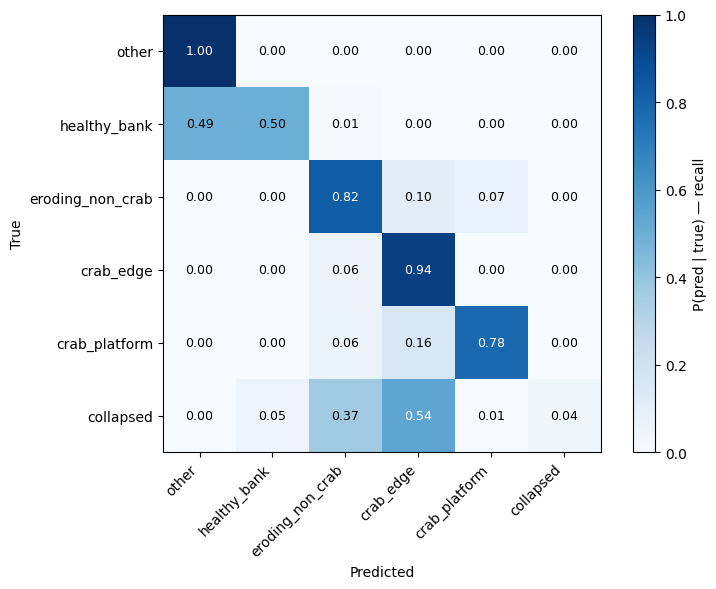


=== priority_all ===
  Pixels: 896,120/896,120 kept  ·  0 abstained (0.0%)


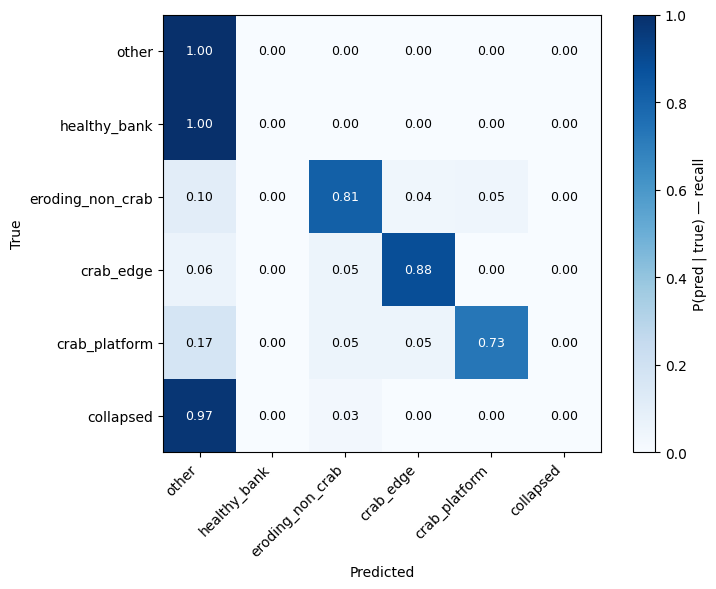


=== priority_crab_only ===
  Pixels: 896,120/896,120 kept  ·  0 abstained (0.0%)


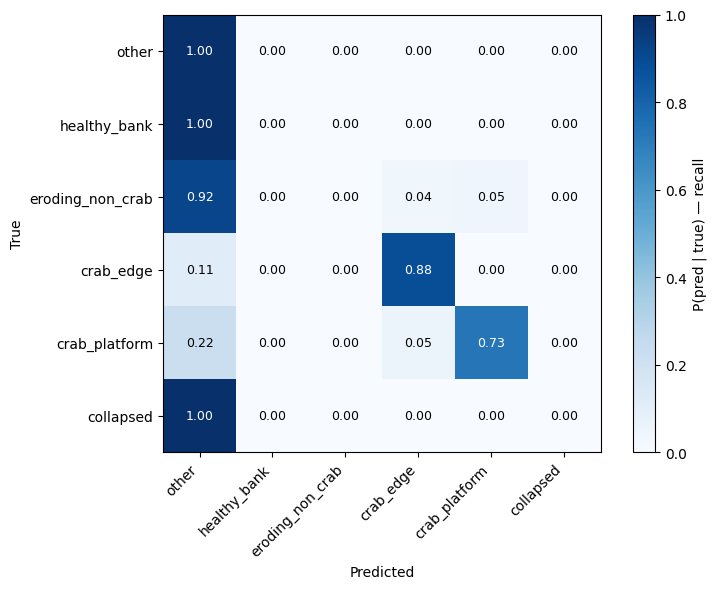

In [35]:
import sklearn.metrics
import numpy as np
import collections


# ─── Helper: evaluate one rule (handles abstention) ───
def evaluate_rule(true, pred, class_names, abstain_label=255):
    """Show confusion matrix for non-abstained pixels, report abstention rate."""
    valid = pred != abstain_label
    n_abstained = int((~valid).sum())
    pct = 100 * n_abstained / len(pred) if len(pred) else 0.0
    print(f"  Pixels: {valid.sum():,}/{len(pred):,} kept  ·  "
          f"{n_abstained:,} abstained ({pct:.1f}%)")
    if valid.sum() == 0:
        print("  (no predictions to score)")
        return
    cm = sklearn.metrics.confusion_matrix(
        true[valid], pred[valid], labels=range(len(class_names))
    )
    mu.display_confusion_matrix(cm, class_names, normalize='recall')


# ─── All rules to try ───
class_names = list(Config.CLASS_NAMES.values())

rules = [
    # Pure argmax (no thresholding, no abstain)
    ('argmax',
        lambda p: rule_argmax(p)),

    # Argmax + abstain on low max-confidence
    ('argmax_abstain_05',
        lambda p: mu.rule_argmax_abstain(p, min_confidence=0.5)),
    ('argmax_abstain_07',
        lambda p: mu.rule_argmax_abstain(p, min_confidence=0.7)),

    # Argmax + abstain on close top-2 (catches "tied" pixels)
    ('margin_abstain_015',
        lambda p: mu.rule_margin_abstain(p, min_margin=0.15)),
    ('margin_abstain_025',
        lambda p: mu.rule_margin_abstain(p, min_margin=0.25)),

    # Argmax + abstain on high entropy (catches spread distributions)
    ('entropy_abstain_15',
        lambda p: mu.rule_entropy_abstain(p, max_entropy=1.5)),

    # Soft cascade — sum P(banks) > threshold, then argmax among banks
    ('soft_cascade_05',
        lambda p: rule_soft_cascade(p, bank_threshold=0.5)),
    ('soft_cascade_07',
        lambda p: rule_soft_cascade(p, bank_threshold=0.7)),

    # Priority — walk classes in PRIORITY order; first to pass threshold wins
    ('priority_all',
        lambda p: rule_priority(p, Config.CONFIDENCE_THRESHOLDS, Config.PRIORITY)),
    ('priority_crab_only',
        lambda p: rule_priority(p, Config.CONFIDENCE_THRESHOLDS, [5, 4, 3])),
]


# ─── Run each rule ───
for name, rule_fn in rules:
    print(f"\n{'='*70}\n=== {name} ===\n{'='*70}")
    pred = rule_fn(probs)
    evaluate_rule(true, pred, class_names)

In [36]:
print(f"\n{'='*70}\n=== margin tie diagnostics ===\n{'='*70}")
sorted_idx = np.argsort(probs, axis=1)
sorted_probs = np.take_along_axis(probs, sorted_idx, axis=1)
margin = sorted_probs[:, -1] - sorted_probs[:, -2]

for thresh in [0.15, 0.25]:
    tied = margin < thresh
    print(f"\nmargin < {thresh}: {tied.sum():,} pixels ({100*tied.mean():.1f}%)")
    if tied.sum() == 0:
        continue
    top1 = sorted_idx[:, -1][tied]
    top2 = sorted_idx[:, -2][tied]
    pairs = [tuple(sorted([t1, t2])) for t1, t2 in zip(top1, top2)]
    counter = collections.Counter(pairs)
    print("  Top tied pairs (class_a ↔ class_b → count):")
    for (a, b), n in counter.most_common(5):
        print(f"    {class_names[a]:18s} ↔ {class_names[b]:18s}  {n:,}")


=== margin tie diagnostics ===

margin < 0.15: 10,599 pixels (1.2%)
  Top tied pairs (class_a ↔ class_b → count):
    eroding_non_crab   ↔ crab_edge           4,474
    crab_edge          ↔ crab_platform       1,922
    other              ↔ healthy_bank        1,599
    eroding_non_crab   ↔ crab_platform       1,404
    crab_edge          ↔ collapsed           392

margin < 0.25: 15,143 pixels (1.7%)
  Top tied pairs (class_a ↔ class_b → count):
    eroding_non_crab   ↔ crab_edge           6,687
    crab_edge          ↔ crab_platform       3,146
    eroding_non_crab   ↔ crab_platform       2,188
    other              ↔ healthy_bank        1,701
    crab_edge          ↔ collapsed           490


<img src='https://www.dropbox.com/scl/fi/oyu1fdcvn21iejfclvunu/Screenshot-2026-06-08-at-11.58.13-AM.png?rlkey=kkf2krz8plyov1mcfxapqswty&dl=1'>

In [37]:
foobar()

NameError: name 'foobar' is not defined

#Save for use in production